# SPLICE Demo

Decomposes geospatial embeddings into sparse nonnegative combinations of text concept embeddings using SPLICE.

Loads the alignment model from a checkpoint directory and concepts from a JSON file.

## Setup

In [1]:
import sys
import json
import os
from pathlib import Path
import yaml

In [2]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

In [3]:
REPO_ROOT = Path("..").resolve()
SPLICE_DIR = REPO_ROOT / "src" / "explainability" / "splice"
LOCATION_TEXT_ALIGNMENT_DIR = SPLICE_DIR / "location_text_alignment"

In [4]:
for p in [str(LOCATION_TEXT_ALIGNMENT_DIR), str(SPLICE_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [5]:
from eval_reconstruction import load_model, load_concept_embeddings, load_latlons, build_splice, compute_reconstruction

/home/libe2152/miniconda3/envs/xemb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [6]:
CONFIG_PATH = REPO_ROOT / "configs" / "eval_reconstruction.yaml"
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

In [7]:
MODEL_NAME = "climplicit"

In [8]:
model_cfg  = cfg["models"][MODEL_NAME]

MODEL_PATH = (
    Path(model_cfg["root"]).expanduser()
    / model_cfg["checkpoint"]
)

L1_PENALTY = model_cfg["l1_penalty"]
CONCEPT_SET = Path(cfg["concept_set"]).expanduser()
DENSE_GRID_CSV = Path(cfg["datasets"]["dense_grid"]).expanduser()


In [9]:
print(f"Model : {MODEL_PATH}")
print(f"L1 : {L1_PENALTY}")

Model : /home/libe2152/outputs/explainable-earth-embeddings/git-10M/txt-open_clip_vit_l__loc-climplicit__tproj-linear__lproj-none__tft-lora__lft-only_proj__lora_r-8__loss-clip_symmetric__lr-0.0001__h-a341ad85/best.pt
L1 : 0.175


In [10]:
BATCH_SIZE = 512
PROMPT = "An image of a {concept}"

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Load Alignment Model

In [12]:
model = load_model(MODEL_PATH, device)
print("Model loaded.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3140.58it/s]
[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder

Model loaded.


## Load Concepts

In [13]:
with open(CONCEPT_SET) as f:
    concepts = json.load(f)

emb_concepts = load_concept_embeddings(model, CONCEPT_SET, device)
print(f"Loaded {len(concepts)} concepts, embeddings: {emb_concepts.shape}")

Loaded 1020 concepts, embeddings: torch.Size([1020, 1024])


## Load Dense Grid Sample (reference distribution for SPLICE)

In [14]:
df = pd.read_csv(DENSE_GRID_CSV)
df = df.reset_index(drop=True)
latlons = torch.tensor(df[["lat", "lon"]].values, dtype=torch.float32).to(device)
print(f"Reference points: {latlons.shape}")

Reference points: torch.Size([100000, 2])


## Build SPLICE Model

In [15]:
splice_model = build_splice(model, emb_concepts, latlons, L1_PENALTY, device)

Using ADMM solver...
With rho value 5.0


## Reconstruction Metrics

In [88]:
orig, weights, recon = compute_reconstruction(splice_model, latlons)

100%|██████████| 20/20 [00:12<00:00,  1.59it/s]


In [89]:
mse = F.mse_loss(recon, orig).item()
cos_sim = (recon * orig).sum(dim=1).mean().item()
l0_mean = (weights > 0).float().sum(dim=1).mean().item()

In [90]:
print(
    f"mse: {mse:.6f}\n"
    f"cosine_similarity: {cos_sim:.4f}\n"
    f"mean_active_concepts_l0: {l0_mean:.1f}\n"
    f"num_concepts: {int(weights.shape[1])}\n"
    f"num_samples: {int(len(orig))}"
)

mse: 0.002213
cosine_similarity: 0.4335
mean_active_concepts_l0: 8.2
num_concepts: 1020
num_samples: 10000


## Concept Decompositions

In [16]:
colors = {
    "Paris":   "#3a86ff",
    "Sahara":  "#e76f51",
    "Siberia": "#588157",
    "Bali":    "#9b5de5",
}

In [17]:
# Replace with desired locations
locations = {
    "Paris":   (48.8584,   2.2945),
    "Sahara":  (22.2348,   7.9586),
    "Siberia": (61.5240, 105.3188),
    "Bali":    (-8.4095, 115.1889),
}

In [18]:
# Number of concepts displayed
TOP_K = 4

In [19]:
def _decompose_latlon(lat, lon):
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    with torch.no_grad():
        raw = splice_model.clip.encode_image(latlon)
        orig_b = F.normalize(raw, dim=1)
        w_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
    return w_b[0]

## Print Concept Decompositions

In [20]:
for name, (lat, lon) in locations.items():
    w = _decompose_latlon(lat, lon)
    top_k = [(c, v) for c, v in sorted(zip(concepts, w.tolist()), key=lambda x: -x[1]) if v > 0][:TOP_K]
    print(f"{name}:")
    for concept, val in top_k:
        print(f"  {concept}: {val:.4f}")
    print()

Paris:
  ramp: 0.0863
  marker: 0.0615
  rooftop: 0.0339
  train: 0.0337

Sahara:
  sandpit: 0.0504
  arid: 0.0362
  pedestrian: 0.0355
  salt: 0.0302

Siberia:
  traffic: 0.0408
  vein: 0.0255
  connection: 0.0237
  streak: 0.0129

Bali:
  compartment: 0.0489
  coastline: 0.0282
  cloud: 0.0272
  grove: 0.0123



## Visualize Concept Decompositions

In [21]:
loc_decompositions = {}
for name, (lat, lon) in locations.items():
    w = _decompose_latlon(lat, lon)
    pairs = [(c, v) for c, v in sorted(zip(concepts, w.tolist()), key=lambda x: -x[1]) if v > 0][:TOP_K]
    loc_decompositions[name] = pairs

all_vals = [v for pairs in loc_decompositions.values() for _, v in pairs]
xmax = max(all_vals) * 1.12 if all_vals else 1.0


plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size":       14,
    "axes.titlesize":  16,
    "axes.labelsize":  14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 13,
})

Paris


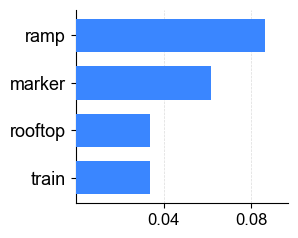

Sahara


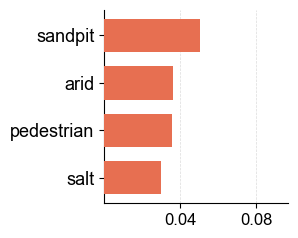

Siberia


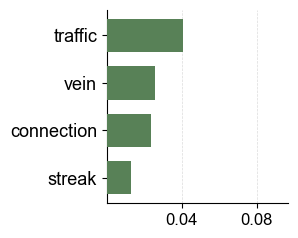

Bali


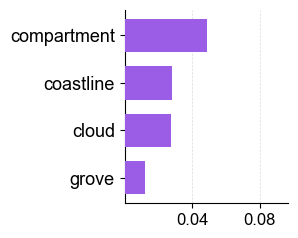

In [22]:
for name, (lat, lon) in locations.items():
    pairs = loc_decompositions[name]
    if not pairs:
        continue

    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    fig, ax = plt.subplots(figsize=(3.2, 2.6))
    ax.barh(y, vals, height=0.7, color=colors[name], edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([c for c in labels])
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    #ax.set_title(name)
    print(name)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.grid(axis="x", linewidth=0.5, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
    plt.tight_layout()
    plt.show()

## Polygon / Region Decomposition

Instead of a single point, you can compute SPLICE over a **grid of points inside a polygon** and aggregate the weights.

**Two ways to define the polygon:**

**Option: inline coordinates** using `shapely.geometry.Polygon`.  
Shapely uses **(lon, lat)** order (x = longitude, y = latitude).

**Option: shapefile** loaded with `geopandas`.  
Any format GDAL supports (`.shp`, `.geojson`, `.gpkg`, etc.) works.  
Call `.to_crs("EPSG:4326")` first if the file is not already in WGS-84.

After choosing a polygon, `grid_in_polygon` samples it on a regular degree grid, then SPLICE weights are averaged across all interior points to give a single regional decomposition.

In [23]:
import geopandas as gpd
from shapely.geometry import Point, Polygon

In [24]:
def grid_in_polygon(polygon, resolution_deg=0.5):
    """Return (lat, lon) pairs on a regular grid that fall inside polygon.

    polygon      – shapely Polygon/MultiPolygon in (lon, lat) / EPSG:4326
    resolution_deg – grid spacing in degrees
    """
    minx, miny, maxx, maxy = polygon.bounds  # minx=lon_min, miny=lat_min
    lons = np.arange(minx, maxx + resolution_deg, resolution_deg)
    lats = np.arange(miny, maxy + resolution_deg, resolution_deg)
    return [
        (lat, lon)
        for lat in lats
        for lon in lons
        if polygon.contains(Point(lon, lat))
    ]

## Region Decompositions from Shapefiles

In [25]:
SHAPEFILE_DIR = Path("~/data/shapefiles/splice_concepts").expanduser()

In [26]:
gdf_fr = gpd.read_file(f"/vsigzip/{SHAPEFILE_DIR}/communes-5m.geojson.gz")
poly_paris = gdf_fr[gdf_fr["nom"] == "Paris"].geometry.iloc[0]

In [27]:
gdf_idn = gpd.read_file(f"zip://{SHAPEFILE_DIR}/gadm41_IDN_shp.zip", layer="gadm41_IDN_1")
poly_bali = gdf_idn[gdf_idn["NAME_1"] == "Bali"].geometry.iloc[0]

In [28]:
gdf_sah = gpd.read_file(f"zip://{SHAPEFILE_DIR}/sahara.zip").to_crs("EPSG:4326")
poly_sahara = gdf_sah.geometry.iloc[0]

In [29]:
SIBERIAN_REGIONS = [
    "Altay", "Gorno-Altay", "Buryat", "Irkutsk", "Kemerovo",
    "Khakass", "Krasnoyarsk", "Novosibirsk", "Omsk", "Tomsk",
    "Tuva", "Zabaykal'ye",
]
gdf_rus = gpd.read_file(f"zip://{SHAPEFILE_DIR}/gadm41_RUS_shp.zip", layer="gadm41_RUS_1")
poly_siberia = gdf_rus[gdf_rus["NAME_1"].isin(SIBERIAN_REGIONS)].dissolve().geometry.iloc[0]


In [30]:
region_polys = {
    "Paris":   poly_paris,
    "Bali":    poly_bali,
    "Sahara":  poly_sahara,
    "Siberia": poly_siberia,
}


In [31]:
for name, poly in region_polys.items():
    print(f"{name}: bounds = {tuple(round(v, 2) for v in poly.bounds)}")

Paris: bounds = (2.22, 48.82, 2.47, 48.9)
Bali: bounds = (114.43, -8.85, 115.71, -8.06)
Sahara: bounds = (-17.07, 9.34, 38.46, 34.61)
Siberia: bounds = (70.42, 49.08, 122.09, 81.28)


In [32]:
RESOLUTION_DEG = 0.5

region_decompositions = {}
for name, poly in region_polys.items():
    pts = grid_in_polygon(poly, RESOLUTION_DEG)
    if not pts:
        c = poly.centroid
        pts = [(c.y, c.x)]  # (lat, lon)
        print(f"{name}: no grid points found, using centroid ({c.y:.4f}, {c.x:.4f})")
    grid_latlons = torch.tensor(pts, dtype=torch.float32, device=device)
    with torch.no_grad():
        raw = splice_model.clip.encode_image(grid_latlons)
        orig_g = F.normalize(raw, dim=1)
        grid_weights = splice_model.decompose(
            F.normalize(orig_g - splice_model.image_mean, dim=1)
        )
    mean_w = grid_weights.mean(0)
    top_k = [
        (c, v)
        for c, v in sorted(zip(concepts, mean_w.tolist()), key=lambda x: -x[1])
        if v > 0
    ][:TOP_K]
    region_decompositions[name] = top_k
    print(f"{name} ({len(pts)} pts):")
    for concept, val in top_k:
        print(f"  {concept}: {val:.4f}")
    print()

Paris: no grid points found, using centroid (48.8566, 2.3429)
Paris (1 pts):
  ramp: 0.0862
  marker: 0.0617
  train: 0.0345
  rooftop: 0.0342

Bali (2 pts):
  compartment: 0.0575
  cloud: 0.0222
  coastline: 0.0208
  forest: 0.0172

Sahara (3717 pts):
  sandpit: 0.0162
  arid: 0.0145
  pedestrian: 0.0124
  sandy: 0.0079

Siberia (3530 pts):
  vein: 0.0088
  connection: 0.0037
  traffic: 0.0028
  glacier: 0.0019



Paris


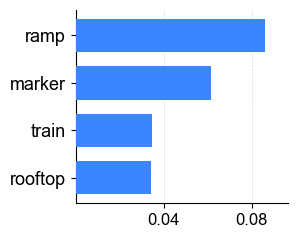

Bali


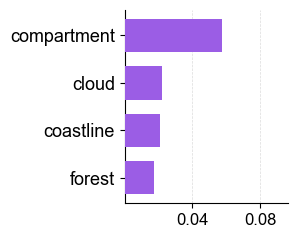

Sahara


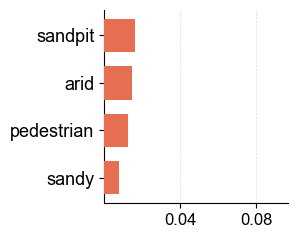

Siberia


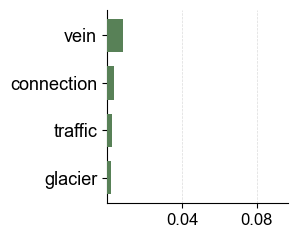

In [33]:
all_region_vals = [v for pairs in region_decompositions.values() for _, v in pairs]
xmax_region = max(all_region_vals) * 1.12 if all_region_vals else 1.0

for name, pairs in region_decompositions.items():
    if not pairs:
        continue

    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    fig, ax = plt.subplots(figsize=(3.2, 2.6))
    ax.barh(y, vals, height=0.7, color=colors[name], edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([c for c in labels])
    ax.invert_yaxis()
    ax.set_xlim(0, xmax_region)
    #ax.set_title(name)
    print(name)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.grid(axis="x", linewidth=0.5, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
    plt.tight_layout()
    fig.savefig(f'{MODEL_NAME}_{name}_region_top_4.png', dpi=300)
    plt.show()